In [13]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
from scipy.stats import pearsonr
import sys
sys.path.insert(0,'..')
from scripts.models.pod.model import RampPOD
warnings.filterwarnings('ignore')
pplt.rc.update({
    'tick.minor':False,
    'savefig.dpi':300,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'legend.fontsize':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal'})

In [14]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
PREDSDIR   = CONFIGS['filepaths']['predictions']
MODELSDIR  = CONFIGS['filepaths']['models']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELS     = CONFIGS['experiments']
NNCONFIG   = MODELS['nn']
SRCONFIG   = MODELS['sr']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
YEARS      = CONFIGS['domain']['years']
MONTHS     = CONFIGS['domain']['months']

In [15]:
url = 'https://psl.noaa.gov/data/correlation/nina34.anom.data'
raw = pd.read_csv(url,sep=r'\s+',header=None,skiprows=1,engine='python')
raw = raw[pd.to_numeric(raw[0],errors='coerce').notna()]
raw = raw.iloc[:,:13].apply(pd.to_numeric,errors='coerce')

nino = {}
for _,row in raw.iterrows():
    year = int(row[0])
    if YEARS[0]<=year<=YEARS[-1]:
        jja = np.nanmean(row[MONTHS].to_numpy())
        if np.isfinite(jja):
            nino[year] = float(jja)

In [44]:
def load_all_splits(var):
    pieces = []
    for split in ['train','valid','test']:
        path = os.path.join(SPLITSDIR,f'{split}.h5')
        with xr.open_dataset(path,engine='h5netcdf') as ds:
            if var in ds:
                pieces.append(ds[var].load())
    if not pieces:
        raise KeyError(f'{var!r} not found in any split file')
    return xr.concat(pieces,dim='time')

def annual_q95(da,years):
    slices = []
    for year in years:
        mask = da.time.dt.year==year
        if not mask.any():
            continue
        q = da.sel(time=mask).quantile(0.95,dim='time',skipna=True)
        if 'quantile' in q.coords:
            q = q.drop_vars('quantile')
        slices.append(q.expand_dims(year=[year]))
    return xr.concat(slices,dim='year')

def pearson_map(q95da,ninodict):
    years = q95da.year.values
    nino  = np.array([ninodict.get(int(year),np.nan) for year in years],dtype=float)
    q95values = q95da.values.astype(float)
    nlat,nlon = q95values.shape[1],q95values.shape[2]
    rmap = np.full((nlat,nlon),np.nan)
    pmap = np.full((nlat,nlon),np.nan)
    for i in range(nlat):
        for j in range(nlon):
            values = q95values[:,i,j]
            ok   = np.isfinite(values)&np.isfinite(nino)
            if ok.sum()>=5:
                rmap[i,j],pmap[i,j] = pearsonr(nino[ok],values[ok])
    coords = {'lat':q95da.lat,'lon':q95da.lon}
    return (xr.DataArray(rmap,dims=['lat','lon'],coords=coords),
            xr.DataArray(pmap,dims=['lat','lon'],coords=coords))

def flatten(a,b):
    a,b  = a.values.ravel(),b.values.ravel()
    mask = np.isfinite(a) & np.isfinite(b)
    return a[mask],b[mask]

def fit_empirical_qm(a,b,nquantiles=2000,eps=1e-8):
    apos,bpos = a[a>0],b[b>0]
    quantiles = np.linspace(0,1,nquantiles)
    aq = np.quantile(apos,quantiles) if len(apos)>0 else np.array([0.])
    bq = np.quantile(bpos,quantiles) if len(bpos)>0 else np.array([0.])
    aq = np.maximum.accumulate(aq)
    bq = np.maximum.accumulate(bq)
    def qm(x):
        x   = np.maximum(np.asarray(x,float),0)
        out = np.zeros_like(x)
        out[x>0] = np.interp(x[x>0],aq,bq,left=bq[0],right=bq[-1])
        return out
    return qm

def _load_kernel_weights(weightsfrom):
    wlist = []
    for seed in NNCONFIG['seeds']:
        wpath = os.path.join(WEIGHTSDIR,f'{weightsfrom}_{seed}_weights.nc')
        with xr.open_dataset(wpath,engine='h5netcdf') as wds:
            wlist.append(wds['k'].load())
    return xr.concat(wlist,dim='seed').mean('seed')

def _kernel_integrate_fields(fieldvars, splitvars, weightsmean):
    dsig_da = splitvars['dsig']

    if 'time' in dsig_da.dims:
        dsig_da = dsig_da.mean(dim='time')

    dsig = np.asarray(dsig_da.transpose('sig').values).reshape(-1)

    result = {}

    for var in fieldvars:
        da = splitvars[var]
        spacedims = [d for d in da.dims if d != 'sig']

        arr = da.transpose(*spacedims, 'sig').values

        wda = weightsmean.sel(field=var)
        w = np.asarray(wda.values).reshape(-1)

        integ = (
            arr.reshape(-1, arr.shape[-1])
            * w[None, :]
            * dsig[None, :]
        ).sum(axis=1)

        coords = {d: da.coords[d] for d in spacedims if d in da.coords}
        result[var] = xr.DataArray(
            integ.reshape(arr.shape[:-1]),
            dims=spacedims,
            coords=coords,
        )

    return result
    
def eval_nn_allyears(name,runconfig):
    import torch
    from scripts.models.nn.classes.factory import build_model
    from scripts.models.nn.classes.dataset import FieldDataset,load_split
    from scripts.models.nn.classes.inferencer import Inferencer
    fieldvars = runconfig['fieldvars']
    localvars = runconfig.get('localvars',[])
    haskernel = runconfig['kind'] != 'baseline'
    seeds     = NNCONFIG['seeds']
    device    = 'cuda' if torch.cuda.is_available() else 'cpu'
    with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
        stats = json.load(f)
    pieces = []
    for split in ['train','valid','test']:
        filepath = os.path.join(PREDSDIR,f'{name}_{split}_predictions.nc')
        if os.path.exists(filepath):
            with xr.open_dataset(filepath) as ds:
                pred = ds['tp'].load()
                if 'seed' in pred.dims:
                    pred = pred.mean('seed')
                pieces.append(pred)
            continue
        print(f'  {name}: evaluating {split} inline on {device}...')
        fields,local,pr,dsig,nlevs,valid,refda = load_split(split,fieldvars,localvars,SPLITSDIR,targetvar='tp')
        dataset    = FieldDataset(fields,local,pr,dsig)
        dataloader = torch.utils.data.DataLoader(dataset,batch_size=NNCONFIG['batchsize'],shuffle=False,num_workers=0)
        seedpreds = []
        for seed in seeds:
            checkpoint = os.path.join(MODELSDIR,'nn',f'{name}_{seed}.pth')
            if not os.path.exists(checkpoint):
                print(f'  Checkpoint not found: {checkpoint}')
                return None
            model = build_model(name,runconfig,nlevs)
            model.load_state_dict(torch.load(checkpoint,map_location='cpu'))
            inferencer = Inferencer(model.to(device),dataloader,device)
            preds,_ = inferencer.predict(haskernel)
            seedpreds.append(preds)
            del model,inferencer
        flatavg = np.mean(seedpreds,axis=0)
        grid = np.full(valid.shape,np.nan,dtype=np.float32)
        grid[valid] = flatavg
        native = np.maximum(np.expm1(grid*stats['tp_std']+stats['tp_mean']),0.0).reshape(refda.shape)
        pieces.append(xr.DataArray(native,dims=refda.dims,coords=refda.coords))
    if not pieces:
        return None
    return xr.concat(pieces,dim='time')

In [22]:
trainds = xr.open_dataset(os.path.join(SPLITSDIR,'train.h5'),engine='h5netcdf')[['tp','pr']].load()
validds = xr.open_dataset(os.path.join(SPLITSDIR,'valid.h5'),engine='h5netcdf')[['tp','pr']].load()
era5  = xr.concat([trainds.tp,validds.tp],dim='time')
imerg = xr.concat([trainds.pr,validds.pr],dim='time')
era5,imerg = xr.align(era5,imerg,join='inner')
era5,imerg = flatten(era5,imerg)
qmfunction = fit_empirical_qm(era5,imerg)
del trainds,validds,era5,imerg

In [23]:
imergall = load_all_splits('pr')
q95imerg = annual_q95(imergall,YEARS)
rimerg,pimerg = pearson_map(q95imerg,nino)
del imergall,q95imerg

In [24]:
bl = load_all_splits('bl')
with np.load(os.path.join(MODELSDIR,'pod','pod_bl.npz')) as d:
    pod = RampPOD(float(d['alpha']),float(d['xcrit']))
predpod = xr.DataArray(pod.forward(bl).reshape(bl.shape),dims=bl.dims,coords=bl.coords)
qmpod   = xr.apply_ufunc(qmfunction,predpod,vectorize=False)
q95pod  = annual_q95(qmpod,YEARS)
rpod,ppod = pearson_map(q95pod,nino)
del bl,predpod,qmpod,q95pod

In [25]:
import gc
import torch
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

base = eval_nn_allyears('base_all',NNCONFIG['runs']['base_all'])
if base is not None:
    qmbase  = xr.apply_ufunc(qmfunction,base,vectorize=False)
    q95base = annual_q95(qmbase,YEARS)
    rbase,pbase = pearson_map(q95base,nino)
    del base,qmbase,q95base
else:
    rbase,pbase = None,None

  base_all: evaluating train inline on cuda...
  base_all: evaluating test inline on cuda...


In [29]:
kernel = eval_nn_allyears('param_gauss_all',NNCONFIG['runs']['param_gauss_all'])
if kernel is not None:
    qmkernel  = xr.apply_ufunc(qmfunction,kernel,vectorize=False)
    q95kernel = annual_q95(qmkernel,YEARS)
    rkernel,pkernel = pearson_map(q95kernel,nino)
    del kernel,qmkernel,q95kernel
else:
    rkernel,pkernel = None,None

  param_gauss_all: evaluating train inline on cuda...
  param_gauss_all: evaluating test inline on cuda...


In [53]:
piecesnorm = []
for split in ['train','valid','test']:
    normpath = os.path.join(SPLITSDIR,f'norm_{split}.h5')
    with xr.open_dataset(normpath,engine='h5netcdf') as ds:
        piecesnorm.append({v:ds[v].load() for v in ds.data_vars})

allvars = sorted(set().union(*[set(p.keys()) for p in piecesnorm]))
svars   = {v:xr.concat([p[v] for p in piecesnorm if v in p],dim='time') for v in allvars}
if 'dsig' not in svars:
    with xr.open_dataset(os.path.join(SPLITSDIR,'train.h5'),engine='h5netcdf') as ds:
        svars['dsig'] = ds['dsig'].load()

_sr_fieldvars = list(SRCONFIG['runs']['sr_gauss_all']['fieldvars'])
srinteg = _kernel_integrate_fields(_sr_fieldvars,svars,_load_kernel_weights('param_gauss_all'))
srrefda = svars['tp']
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    srstats = json.load(f)

def eval_sr_run(name, runconfig):
    filepath = os.path.join(MODELSDIR, 'sr', f'{name}_equations.csv')
    if not os.path.exists(filepath):
        print(f'  {name}: no equations file, skipping')
        return None, None, None, None

    eqdf = pd.read_csv(filepath)
    bestrow = eqdf.loc[eqdf['loss'].idxmin()]
    eqstr = str(bestrow['sympy_format'])
    compl = int(bestrow['complexity'])

    print(f'  {name} (complexity={compl}): {eqstr}')

    ns = {
        'Abs': np.abs,
        'abs': np.abs,
        'sqrt': np.sqrt,
        'exp': np.exp,
        'log': np.log,
        'sin': np.sin,
        'cos': np.cos,
        '__builtins__': {}
    }

    for v, da in srinteg.items():
        ns[v] = da.transpose('time', 'lat', 'lon').values.ravel()

    for v in runconfig.get('localvars', []):
        if v not in svars:
            continue

        da = svars[v]

        extra = [d for d in da.dims if d not in ('time', 'lat', 'lon')]
        if extra:
            da = da.mean(dim=extra)

        # Static variables may have fake split-time length, e.g. lf: time=3
        if 'time' in da.dims and da.sizes['time'] != srrefda.sizes['time']:
            da = da.mean(dim='time')

        # Broadcast static/spatial variables to full target grid
        da = da.broadcast_like(srrefda)

        ns[v] = da.transpose('time', 'lat', 'lon').values.ravel()

    ypredn = np.asarray(eval(eqstr, ns), dtype=float)

    tshape = srrefda.values.ravel().shape
    if ypredn.shape == ():
        ypredn = np.full(tshape, float(ypredn))

    ypredmm = np.maximum(
        np.expm1(np.clip(ypredn, None, 20) * srstats['tp_std'] + srstats['tp_mean']),
        0.0
    )

    srda = xr.DataArray(
        ypredmm.reshape(srrefda.shape),
        dims=srrefda.dims,
        coords=srrefda.coords
    )

    qmsr = xr.apply_ufunc(qmfunction, srda, vectorize=False)
    r, p = pearson_map(annual_q95(qmsr, YEARS), nino)

    return r, p, eqstr, compl

srresults = {}
for _name,_rc in SRCONFIG['runs'].items():
    srresults[_name] = eval_sr_run(_name,_rc)

rsr,psr  = srresults.get('sr_gauss_all',(None,None,None,None))[:2]
_,_,sreqstr,srcompl = srresults.get('sr_gauss_all',(None,None,None,None))

del svars,srinteg

  sr_gauss_all (complexity=20): rh**3 + (lf - 1.5446084)**2*(thetae - thetaestar - Abs(shf - 1*(-0.53779)) - 1*0.3326239)
  sr_gauss_all_v3 (complexity=26): rh**3 + (2.2723532 - lf)*(shf*(sqrt(lf) - 0.96795124) + thetae - thetaestar - 0.476384) - 0.93757284
  sr_gauss_all_v4 (complexity=26): 1.47331060792753*rh**3 + thetae - (1.3223968 - exp(shf))*(3.0321252*sqrt(lf) - 2.89398084817795) - 1.2346294


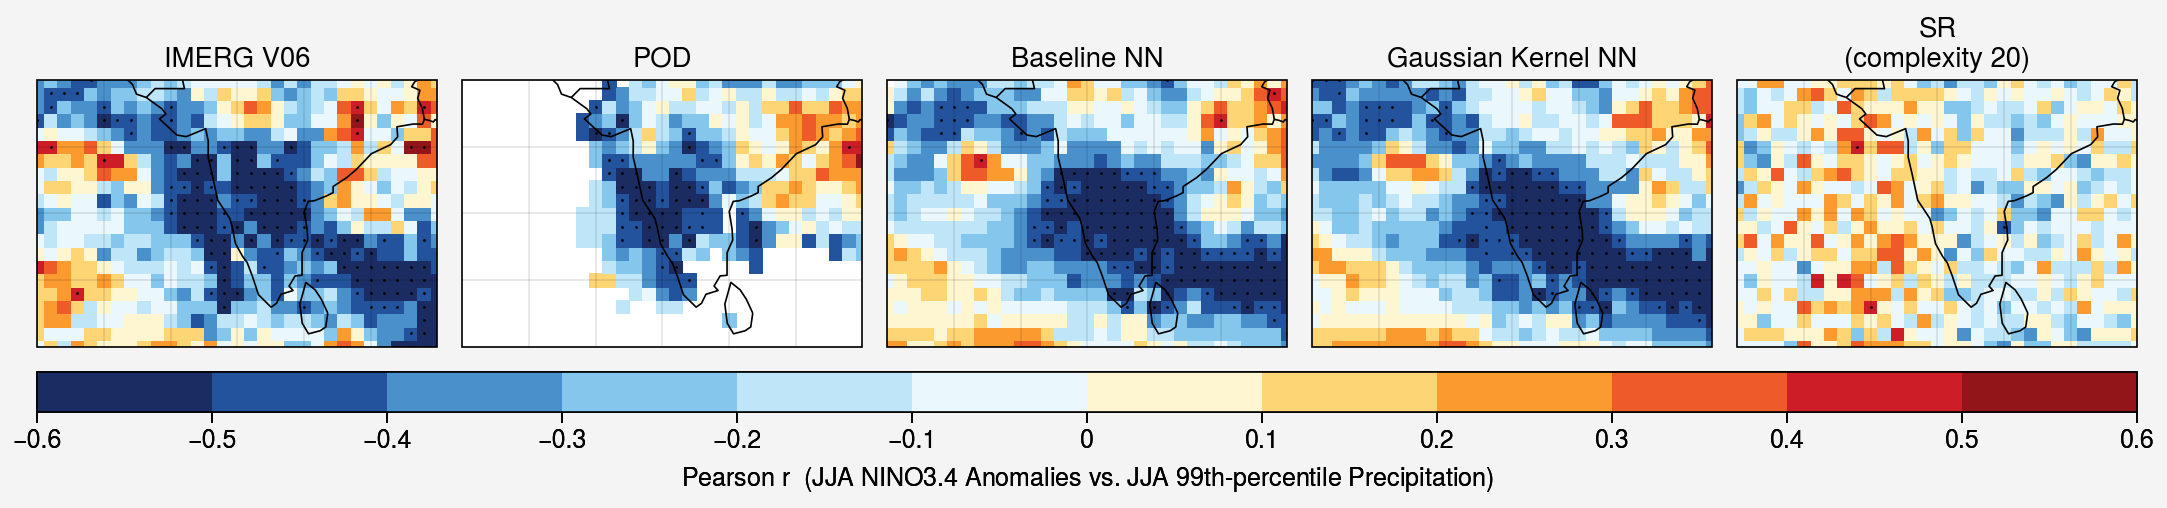

In [54]:
srlabel = f'SR\n(complexity {srcompl})' if srcompl is not None else 'SR'
PANELS  = [
    (rimerg,pimerg,'IMERG V06'),
    (rpod,ppod,'POD'),
    (rbase,pbase,'Baseline NN'),
    (rkernel,pkernel,'Gaussian Kernel NN'),
    (rsr,psr,srlabel),]

fig,axs = pplt.subplots(ncols=5,proj='cyl',refwidth=2)
axs.format(coast=True,borders=True,latlim=(LATRANGE[0],LATRANGE[1]),lonlim=(LONRANGE[0],LONRANGE[1]),latlines=5,lonlines=5)
mappable = None
for ax,(r,p,title) in zip(axs,PANELS):
    ax.format(title=title)
    if r is None:
        continue
    m = ax.pcolormesh(r.lon.values,r.lat.values,r.values,cmap='ColdHot',vmin=-0.7,vmax=0.7,N=15)
    if mappable is None:
        mappable = m
    if p is not None: # Stippling marks grid points significant at p < 0.05 (|r| > 0.433 for n=21)
        pmask = p.values<0.05
        if pmask.any():
            lons2d,lats2d = np.meshgrid(r.lon.values,r.lat.values)
            ax.scatter(lons2d[pmask],lats2d[pmask],color='k',s=1,zorder=5,linewidths=0)

fig.colorbar(mappable,loc='b',label='Pearson $r$  (JJA NINO3.4 Anomalies vs. JJA 99th-percentile Precipitation)')
# fig.save('../figs/fig_enso.jpg')
pplt.show()

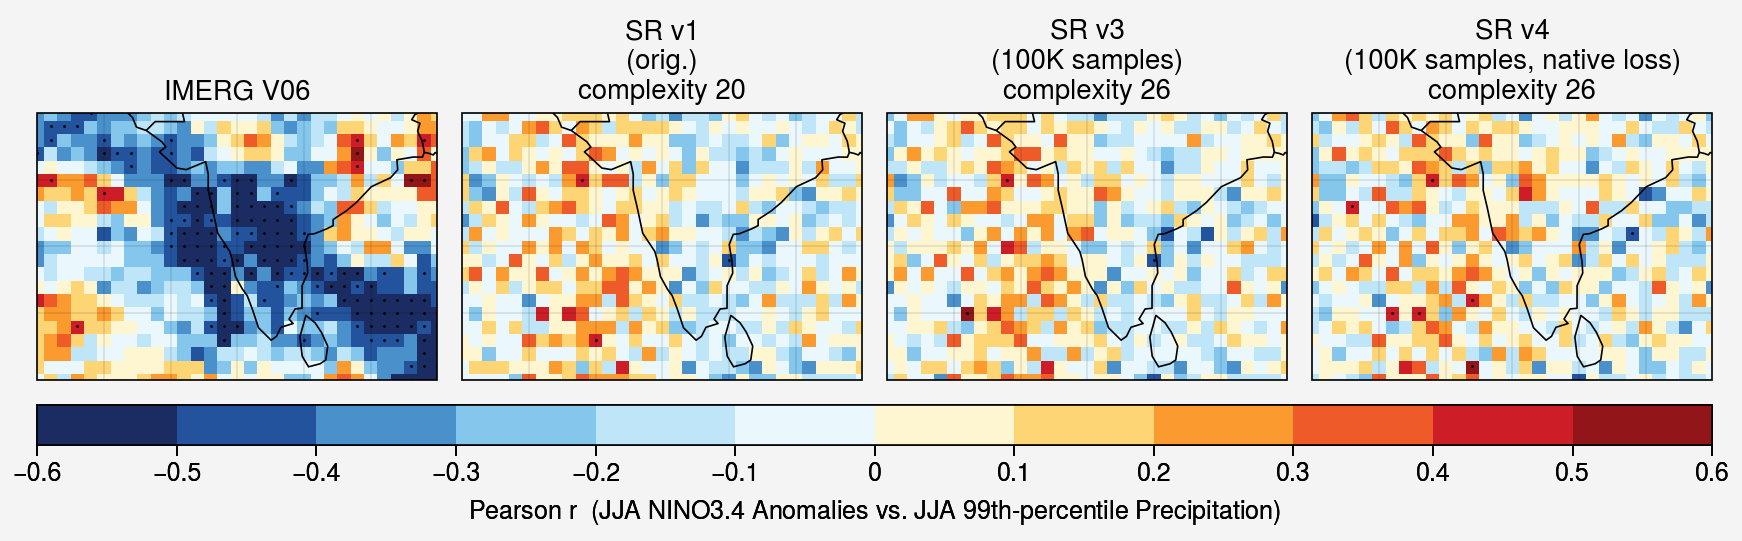

In [56]:
# IMERG reference alongside all available SR model ENSO correlation maps.
# Goal: more skillful SR models should better recover the El Niño enhancement
# of extreme precipitation (positive r over wet regions) seen in Hill et al. (2025).

SRLABELS = {
    'sr_gauss_all':'SR v1\n(orig.)',
    'sr_gauss_all_v3':'SR v3\n(100K samples)',
    'sr_gauss_all_v4':'SR v4\n(100K samples, native loss)',}
available = [
    (name,srresults[name]) for name in SRLABELS
    if name in srresults and srresults[name][0] is not None]
if not available:
    print('No SR model results available yet — run train.py for sr_gauss_all_v3/v4 first.')
else:
    ncols = 1+len(available)
    fig,axs = pplt.subplots(ncols=ncols,proj='cyl',refwidth=2)
    axs.format(coast=True,borders=True,latlim=(LATRANGE[0],LATRANGE[1]),lonlim=(LONRANGE[0],LONRANGE[1]),latlines=5,lonlines=5,)
    mappable = None
    axs[0].format(title='IMERG V06')
    m = axs[0].pcolormesh(rimerg.lon.values,rimerg.lat.values,rimerg.values,cmap='ColdHot',vmin=-0.7,vmax=0.7,N=15)
    mappable = m
    if pimerg is not None:
        pmask = pimerg.values<0.05
        if pmask.any():
            lons2d,lats2d = np.meshgrid(rimerg.lon.values,rimerg.lat.values)
            axs[0].scatter(lons2d[pmask],lats2d[pmask],c='k',s=1,zorder=5,linewidths=0)
    for ci,(name,(r,p,eqstr,compl)) in enumerate(available):
        ax    = axs[ci+1]
        label = SRLABELS[name]
        if compl is not None:
            label += f'\ncomplexity {compl}'
        ax.format(title=label)
        m = ax.pcolormesh(r.lon.values,r.lat.values,r.values,cmap='ColdHot',vmin=-0.7,vmax=0.7,N=15)
        if p is not None:
            pmask = p.values<0.05
            if pmask.any():
                lons2d,lats2d = np.meshgrid(r.lon.values,r.lat.values)
                ax.scatter(lons2d[pmask],lats2d[pmask],c='k',s=1,zorder=5,linewidths=0)
    fig.colorbar(mappable,loc='b',label='Pearson $r$  (JJA NINO3.4 Anomalies vs. JJA 99th-percentile Precipitation)',)
    # fig.save('../figs/fig_enso_sr_models.jpg')
    pplt.show()